In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, label_binarize
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix, precision_recall_curve, auc, recall_score

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

print("Library configuration complete!")

Library configuration complete!


In [ ]:
def combine_files(path):
    print("\n----------------------------------------")
    print("Folder name:", path)
    
    if not os.path.exists(path):
        print(f"❌ Error: Directory does not exist: {path}")
        return []
    
    filenames = [f for f in os.listdir(path) if f.endswith('.csv')]
    print("Number of CSV files:", len(filenames))
    
    dfs = []
    try:
        for filename in filenames:
            file_path = os.path.join(path, filename)
            dfs.append(pd.read_csv(file_path))
        return dfs    
    except Exception as e:
        print("Error reading files:", e)
        return []

try:
    base_path = kagglehub.dataset_download(
        # "ledaihoangnguyentmu/sleep-stage-csv-max-break-time-45-min"
        "ledaihoangnguyentmu/sleep-stage-csv-max-break-time-45"
    )
    print("Original dataset downloaded at:", base_path)

    cassette_dir = os.path.join(base_path, "cassette")
    telemetry_dir = os.path.join(base_path, "telemetry")
    
    if os.path.exists(os.path.join(cassette_dir, "cassette")):
        cassette_dir = os.path.join(cassette_dir, "cassette")
    if os.path.exists(os.path.join(telemetry_dir, "telemetry")):
        telemetry_dir = os.path.join(telemetry_dir, "telemetry")

    cassette_dfs = combine_files(cassette_dir)
    telemetry_dfs = combine_files(telemetry_dir)
    
    if cassette_dfs or telemetry_dfs:
        print("\n✅ Successfully loaded CSV files from cassette and telemetry!")
        print(f"Total DataFrames from cassette: {len(cassette_dfs)}")
        print(f"Total DataFrames from telemetry: {len(telemetry_dfs)}")
    else:
        print("\n❌ No data loaded. Please check the file structure.")

except Exception as e:
    print("A system error occurred:", e)

Original dataset downloaded at: /Users/nguyenle/.cache/kagglehub/datasets/ledaihoangnguyentmu/sleep-stage-csv-max-break-time-45-min/versions/1

----------------------------------------
Folder name: /Users/nguyenle/.cache/kagglehub/datasets/ledaihoangnguyentmu/sleep-stage-csv-max-break-time-45-min/versions/1/cassette
Number of CSV files: 20

----------------------------------------
Folder name: /Users/nguyenle/.cache/kagglehub/datasets/ledaihoangnguyentmu/sleep-stage-csv-max-break-time-45-min/versions/1/telemetry
Number of CSV files: 10

✅ Successfully loaded CSV files from cassette and telemetry!
Total DataFrames from cassette: 20
Total DataFrames from telemetry: 10


In [3]:
CLASS_NAMES = ['Wake', 'N1', 'N2', 'N3', 'REM']
VALID_STAGES = ['Sleep stage W', 'Sleep stage 1', 'Sleep stage 2', 'Sleep stage 3', 'Sleep stage 4', 'Sleep stage R']
MAPPING_STAGES = {'Sleep stage W': 0, 'Sleep stage 1': 1, 'Sleep stage 2': 2, 'Sleep stage 3': 3, 'Sleep stage 4': 3, 'Sleep stage R': 4}
SEED = 42
KFOLD = 5

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=SEED, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
}

results = {m: [] for m in models.keys()}
final_evaluation_data = {m: {'true': [], 'pred': []} for m in models.keys()}
file_majority_labels = [int(df['label'].mode().iloc[0]) for df in cassette_dfs]

def calculate_metrics_v2(y_true, y_pred, y_probs):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3, 4])

    pr_auc_scores = []
    for i in range(5): 
        precision_curve, recall_curve, _ = precision_recall_curve(y_true_bin[:, i], y_probs[:, i])
        precision_recall_auc = auc(recall_curve, precision_curve)
        pr_auc_scores.append(precision_recall_auc)

    macro_pr_auc = np.mean(pr_auc_scores)

    return {
        'acc': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'pr_auc': macro_pr_auc
    }

In [4]:
for fold, (train_idx, val_idx) in enumerate(skf.split(cassette_dfs, file_majority_labels)):
    print(f"\n⚡ Calculating Fold {fold+1} / {KFOLD}..." )

    df_train_fold = pd.concat([cassette_dfs[i] for i in train_idx], ignore_index=True)
    df_test = pd.concat(telemetry_dfs, ignore_index=True)

    feature_cols = [c for c in df_train_fold.columns if c != 'label']
    X_train_raw, y_train = df_train_fold[feature_cols].values, df_train_fold['label'].values
    X_test_raw, y_test = df_test[feature_cols].values, df_test['label'].values

    pipeline_scaler = Pipeline([
        ('log1p', FunctionTransformer(np.log1p, validate=True)),
        ('scaler', StandardScaler())
    ])

    X_train = pipeline_scaler.fit_transform(X_train_raw)
    X_test = pipeline_scaler.transform(X_test_raw)

    xgb_sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

    for name, model in models.items():
        if name == 'XGBoost':
            model.fit(X_train, y_train, sample_weight=xgb_sample_weights)
        else:
            model.fit(X_train, y_train)

        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)

        metrics = calculate_metrics_v2(y_test, preds, probs)
        results[name].append(metrics)

        final_evaluation_data[name]['true'].extend(y_test)
        final_evaluation_data[name]['pred'].extend(preds)

        print('Model: ', name, '| acc: ', metrics['acc'], '| precision: ', metrics['precision'], '| recall: ', metrics['recall'], '| f1 score: ', metrics['f1'], '| pr_auc: ', metrics['pr_auc'])

print("\n🎉 Calculation loop complete! Generating report plots...")


⚡ Calculating Fold 1 / 5...
Model:  Random Forest | acc:  0.6076708363485992 | precision:  0.4786335268902886 | recall:  0.41431606967910983 | f1 score:  0.4027977493942201 | pr_auc:  0.5932755420484169
Model:  XGBoost | acc:  0.577587098108136 | precision:  0.4404442540564082 | recall:  0.5173177874559176 | f1 score:  0.43731510529293016 | pr_auc:  0.5310517491007485

⚡ Calculating Fold 2 / 5...
Model:  Random Forest | acc:  0.6080843585237259 | precision:  0.4313712274919944 | recall:  0.39362216817464113 | f1 score:  0.3852435662644774 | pr_auc:  0.5773808781828776
Model:  XGBoost | acc:  0.6127364829939006 | precision:  0.4528600421745851 | recall:  0.46693676120532884 | f1 score:  0.4323290111964285 | pr_auc:  0.5692848972743334

⚡ Calculating Fold 3 / 5...
Model:  Random Forest | acc:  0.6072573141734725 | precision:  0.5467613346964431 | recall:  0.4005575974128284 | f1 score:  0.38308560989609425 | pr_auc:  0.5547212443485044
Model:  XGBoost | acc:  0.6183190323581103 | precis


📈 DETAILED RESULTS ACROSS FOLDS:

→ Model: Random Forest


,acc,precision,recall,f1,pr_auc
Fold,,,,,
Fold 1,0.6077,0.4786,0.4143,0.4028,0.5933
Fold 2,0.6081,0.4314,0.3936,0.3852,0.5774
Fold 3,0.6073,0.5468,0.4006,0.3831,0.5547
Fold 4,0.6068,0.4288,0.3936,0.3835,0.5666
Fold 5,0.5593,0.4076,0.3227,0.3051,0.5563



→ Model: XGBoost


,acc,precision,recall,f1,pr_auc
Fold,,,,,
Fold 1,0.5776,0.4404,0.5173,0.4373,0.5311
Fold 2,0.6127,0.4529,0.4669,0.4323,0.5693
Fold 3,0.6183,0.4274,0.4450,0.4215,0.5396
Fold 4,0.6148,0.4274,0.4891,0.4379,0.5564
Fold 5,0.6051,0.4496,0.4553,0.4065,0.5673



📊 AVERAGE EVALUATION RESULTS ON INDEPENDENT TEST SET (TELEMETRY):


,acc,precision,recall,f1,pr_auc
Model,,,,,
Random Forest,0.5978,0.4586,0.3849,0.3719,0.5697
XGBoost,0.6057,0.4395,0.4747,0.4271,0.5527


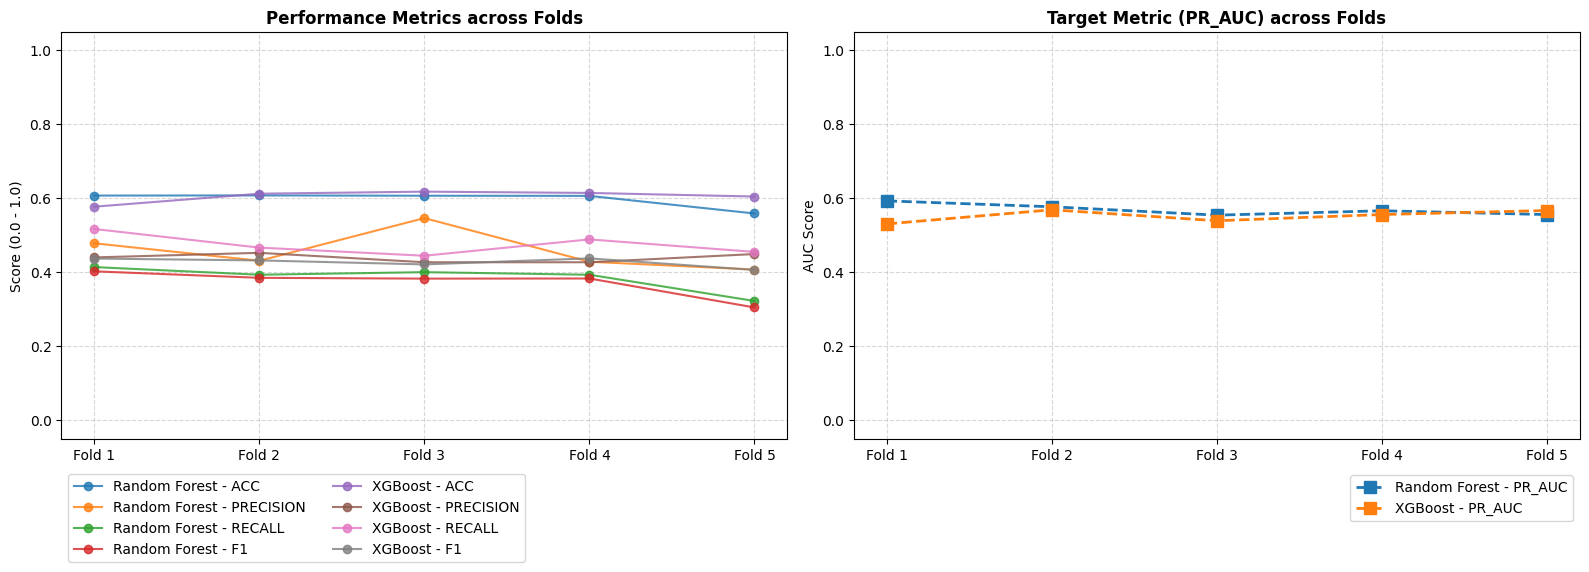

In [5]:
print("\n📈 DETAILED RESULTS ACROSS FOLDS:")

fold_records = []
for model_name, folds_list in results.items():
    for fold_idx, metrics in enumerate(folds_list):
        rec = metrics.copy()
        rec['Model'] = model_name
        rec['Fold'] = f"Fold {fold_idx + 1}"
        fold_records.append(rec)

df_folds = pd.DataFrame(fold_records)

for model_name in results.keys():
    print(f"\n→ Model: {model_name}")
    df_model_folds = df_folds[df_folds['Model'] == model_name].set_index('Fold')
    display(df_model_folds[['acc', 'precision', 'recall', 'f1', 'pr_auc']].round(4))

print("\n📊 AVERAGE EVALUATION RESULTS ON INDEPENDENT TEST SET (TELEMETRY):")
df_summary = df_folds.groupby('Model')[['acc', 'precision', 'recall', 'f1', 'pr_auc']].mean()
display(df_summary.round(4))


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
metrics_to_plot = ['acc', 'precision', 'recall', 'f1']
existing_folds = df_folds['Fold'].unique()

for model_name in results.keys():
    df_m = df_folds[df_folds['Model'] == model_name]
    for metric in metrics_to_plot:
        axes[0].plot(
            df_m['Fold'], df_m[metric], 
            marker='o', linestyle='-', label=f"{model_name} - {metric.upper()}",
            alpha=0.8
        )

axes[0].set_title("Performance Metrics across Folds", fontweight='bold', fontsize=12)
axes[0].set_ylabel("Score (0.0 - 1.0)")
axes[0].set_ylim(-0.05, 1.05)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(loc='lower left', bbox_to_anchor=(0, -0.32), ncol=2)


for model_name in results.keys():
    df_m = df_folds[df_folds['Model'] == model_name]
    axes[1].plot(
        df_m['Fold'], df_m['pr_auc'], 
        marker='s', markersize=8, linestyle='--', linewidth=2,
        label=f"{model_name} - PR_AUC"
    )

axes[1].set_title("Target Metric (PR_AUC) across Folds", fontweight='bold', fontsize=12)
axes[1].set_ylabel("AUC Score")
axes[1].set_ylim(-0.05, 1.05)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(loc='lower right', bbox_to_anchor=(1, -0.22))

plt.tight_layout()
plt.show()

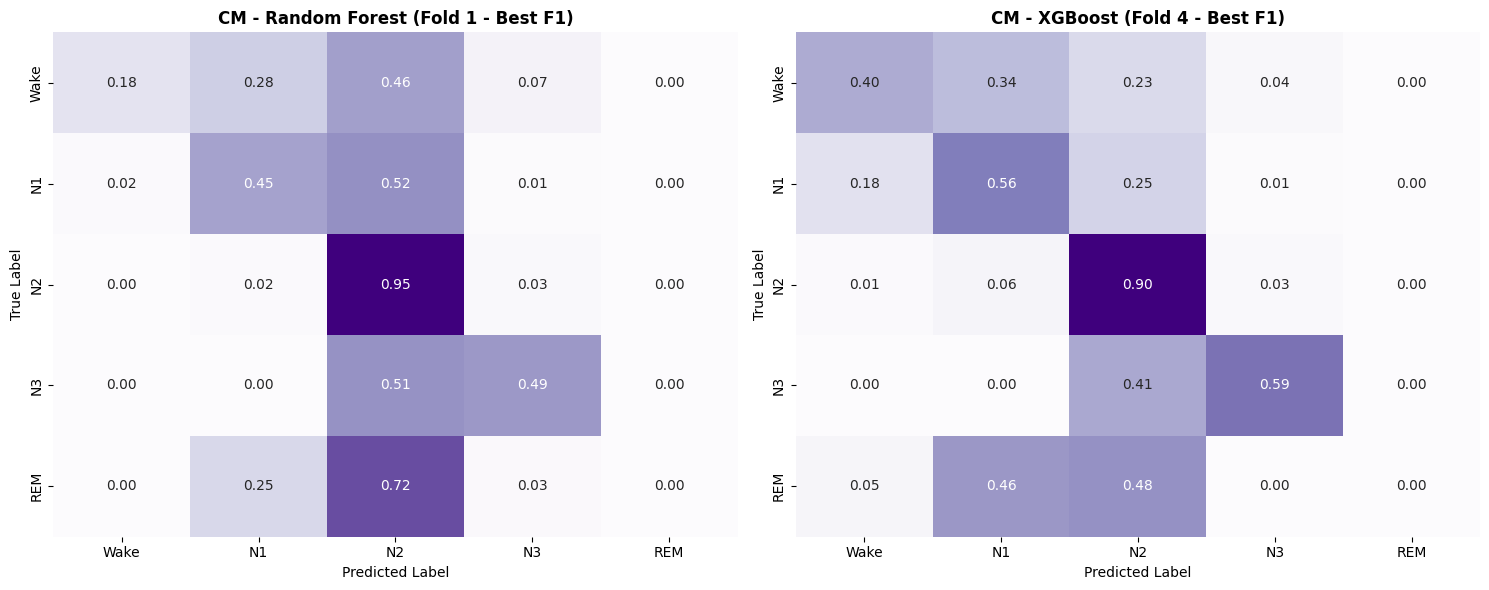

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
num_actual_folds = len(existing_folds)

try:
    for idx, model_name in enumerate(['Random Forest', 'XGBoost']):
        df_m = df_folds[df_folds['Model'] == model_name]
        best_fold_idx = df_m['f1'].idxmax()
        best_fold_num = df_m.loc[best_fold_idx, 'Fold']
        
        total_test_samples = len(final_evaluation_data[model_name]['true']) // num_actual_folds
        
        fold_number = int(best_fold_num.split()[-1]) - 1
        start_pos = fold_number * total_test_samples
        end_pos = start_pos + total_test_samples
        
        y_true_best = final_evaluation_data[model_name]['true'][start_pos:end_pos]
        y_pred_best = final_evaluation_data[model_name]['pred'][start_pos:end_pos]
    
        cm = confusion_matrix(y_true_best, y_pred_best, labels=[0, 1, 2, 3, 4])
        
        cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-9)
    
        sns.heatmap(
            cm_norm, annot=True, fmt=".2f", cmap="Purples",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[idx], cbar=False
        )
    
        axes[idx].set_title(
            f"CM - {model_name} ({best_fold_num} - Best F1)", 
            fontweight='bold', fontsize=12
        )
        axes[idx].set_xlabel("Predicted Label")
        axes[idx].set_ylabel("True Label")
except Exception as e:
    print("Error", e)

plt.tight_layout()
plt.show()